# LAB 02 — Experiment 1: Corpus Statistics
thống kê số documents, sentences,
tokens, vocabulary, số unigram/bigram/trigram, số n-gram chỉ xuất hiện 1 lần (hapax),
và vẽ frequency distribution.



## Bước 1 — Mount Google Drive và khai báo đường dẫn corpus



In [ ]:
from google.colab import drive

drive.mount('/content/drive')

# Sua duong dan cho dung voi vi tri file trong Google Drive cua ban
CORPUS_PATH = "/content/drive/MyDrive/NLP/lab02/c4-train.00000-of-01024-30K.json.gz"
print("Corpus path:", CORPUS_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Corpus path: /content/drive/MyDrive/NLP/lab02/c4-train.00000-of-01024-30K.json.gz


## Bước 2 — Import thư viện và định nghĩa các hàm xử lý

In [ ]:
import gzip
import json
import re
from collections import Counter

import matplotlib.pyplot as plt

SOS = "<s>"
EOS = "</s>"


def load_documents(path, text_field="text", limit=None):
    """
    Doc file corpus, tra ve danh sach document (str).
    """
    is_gzip = path.endswith(".gz")
    opener = gzip.open if is_gzip else open
    is_json_lines = ".json" in path

    docs = []
    with opener(path, "rt", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if is_json_lines:
                obj = json.loads(line)
                docs.append(obj[text_field])
            else:
                docs.append(line)
            if limit is not None and len(docs) >= limit:
                break
    return docs


def split_sentences(text):
    sentences = re.split(r"[.!?]+", text)
    return [s.strip() for s in sentences if s.strip()]


def tokenize(sentence):
    """Tokenize don gian: lowercase + tach tu bang regex."""
    sentence = sentence.lower()
    tokens = re.findall(r"[a-z\u00e0-\u1ef9\u0300-\u036f0-9]+", sentence, flags=re.UNICODE)
    return tokens


def build_ngrams(tokens, n):
    """Sinh danh sach n-gram (dang tuple) tu danh sach token, co padding <s>/</s>."""
    padded = [SOS] * (n - 1) + tokens + [EOS]
    return [tuple(padded[i:i + n]) for i in range(len(padded) - n + 1)]


def corpus_statistics(docs):
    """Tinh toan cac thong ke chinh cua corpus."""
    all_sentences = []
    all_tokens = []
    unigrams = Counter()
    bigrams = Counter()
    trigrams = Counter()

    for doc in docs:
        sentences = split_sentences(doc)
        all_sentences.extend(sentences)
        for sentence in sentences:
            tokens = tokenize(sentence)
            if not tokens:
                continue
            all_tokens.extend(tokens)
            unigrams.update(build_ngrams(tokens, 1))
            bigrams.update(build_ngrams(tokens, 2))
            trigrams.update(build_ngrams(tokens, 3))

    vocab = set(all_tokens)

    stats = {
        "num_documents": len(docs),
        "num_sentences": len(all_sentences),
        "num_tokens": len(all_tokens),
        "vocab_size": len(vocab),
        "num_unique_unigrams": len(unigrams),
        "num_unique_bigrams": len(bigrams),
        "num_unique_trigrams": len(trigrams),
        "num_hapax_unigrams": sum(1 for c in unigrams.values() if c == 1),
        "num_hapax_bigrams": sum(1 for c in bigrams.values() if c == 1),
        "num_hapax_trigrams": sum(1 for c in trigrams.values() if c == 1),
    }
    return stats, unigrams, bigrams, trigrams


def print_report(stats):
    print("= Corpus Statistics =")
    print(f"So documents        : {stats['num_documents']}")
    print(f"So sentences        : {stats['num_sentences']}")
    print(f"So tokens           : {stats['num_tokens']}")
    print(f"Vocabulary size     : {stats['vocab_size']}")
    print()
    header = f"{'Model':<10}{'# unique n-grams':<20}{'# hapax (xuat hien 1 lan)'}"
    print(header)
    print(f"{'Unigram':<10}{stats['num_unique_unigrams']:<20}{stats['num_hapax_unigrams']}")
    print(f"{'Bigram':<10}{stats['num_unique_bigrams']:<20}{stats['num_hapax_bigrams']}")
    print(f"{'Trigram':<10}{stats['num_unique_trigrams']:<20}{stats['num_hapax_trigrams']}")


def plot_frequency_distribution(counter, title, top_k=30):
    """Ve bieu do tan suat cua top_k n-gram xuat hien nhieu nhat (hien inline tren Colab)."""
    most_common = counter.most_common(top_k)
    labels = [" ".join(ngram) for ngram, _ in most_common]
    freqs = [count for _, count in most_common]

    plt.figure(figsize=(10, 5))
    plt.bar(range(len(freqs)), freqs)
    plt.xticks(range(len(freqs)), labels, rotation=90)
    plt.ylabel("Frequency")
    plt.title(title)
    plt.tight_layout()
    plt.show()

## Bước 3 — Cấu hình và load corpus


In [ ]:
LIMIT = None

docs = load_documents(CORPUS_PATH, text_field="text", limit=LIMIT)
print(f"Da load {len(docs)} documents")

Da load 30000 documents


## Bước 4 — Tính thống kê corpus

In [ ]:
stats, unigrams, bigrams, trigrams = corpus_statistics(docs)
print_report(stats)

=== Corpus Statistics ===
So documents        : 30000
So sentences        : 687143
So tokens           : 11089339
Vocabulary size     : 190835

Model     # unique n-grams    # hapax (xuat hien 1 lan)
Unigram   190836              91864
Bigram    2847910             2014939
Trigram   7042586             6012388


## Bước 5 — Frequency distribution (Unigram / Bigram / Trigram)

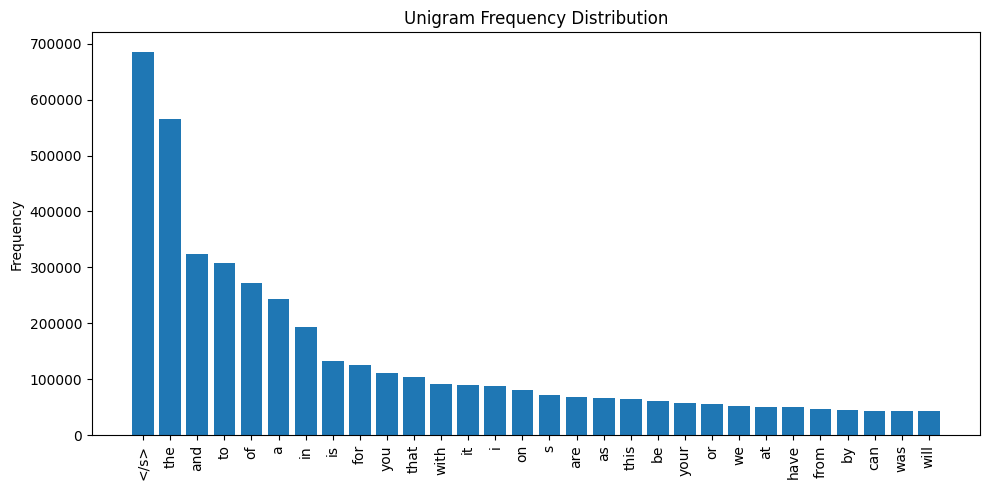

In [ ]:
plot_frequency_distribution(unigrams, "Unigram Frequency Distribution")

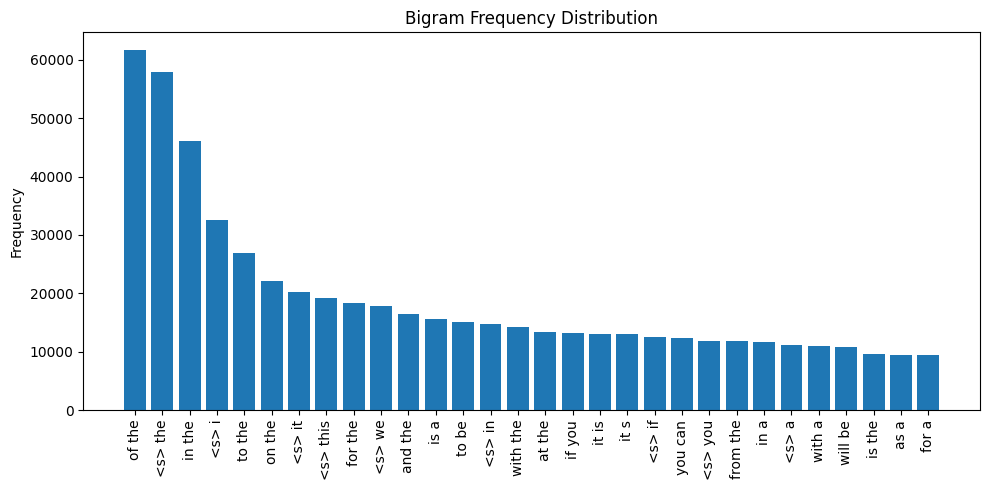

In [ ]:
plot_frequency_distribution(bigrams, "Bigram Frequency Distribution")

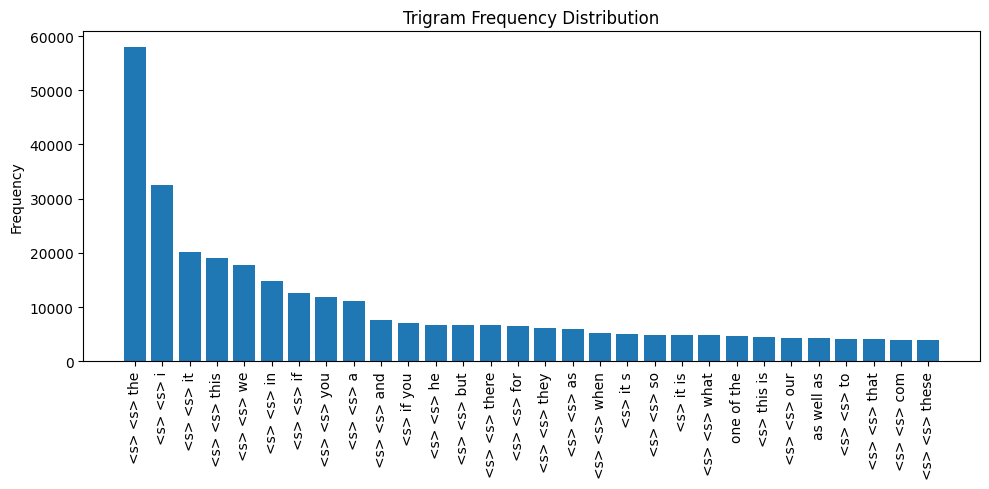

In [ ]:
plot_frequency_distribution(trigrams, "Trigram Frequency Distribution")

## Lưu bảng kết quả ra `results.csv`

In [ ]:
import csv
import os

# Luu results.csv cung thu muc voi corpus tren Google Drive
OUTPUT_DIR = os.path.dirname(CORPUS_PATH)
RESULTS_PATH = os.path.join(OUTPUT_DIR, "results.csv")

# Che do append: neu file da co (tu bai truoc) thi ghi them, khong ghi de
file_exists = os.path.exists(RESULTS_PATH)
with open(RESULTS_PATH, "a", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    if not file_exists:
        writer.writerow(["experiment", "model", "num_unique_ngrams", "num_hapax"])
    writer.writerow(["exp1_corpus_stats", "unigram", stats["num_unique_unigrams"], stats["num_hapax_unigrams"]])
    writer.writerow(["exp1_corpus_stats", "bigram", stats["num_unique_bigrams"], stats["num_hapax_bigrams"]])
    writer.writerow(["exp1_corpus_stats", "trigram", stats["num_unique_trigrams"], stats["num_hapax_trigrams"]])

print("Da luu:", RESULTS_PATH)

Da luu: /content/drive/MyDrive/NLP/lab02/results.csv
